In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.initializers import RandomNormal

IMPORT LIBRARY

In [2]:
df = pd.read_excel("Dry_Bean_Dataset.xlsx")
print(df.shape)
df.head()

(13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


LOAD DATASET

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

In [4]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [5]:
df["Class"].value_counts()


Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

CEK DATASET

In [6]:
df.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

CEK MISSING VALUE

In [7]:
X = df.drop("Class", axis=1)
y = df["Class"]

MEMISAHKAN X DAN Y

In [8]:
X.value_counts()

Area   Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  Eccentricity  ConvexArea  EquivDiameter  Extent    Solidity  roundness  Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4
33518  702.956    277.571399       154.305581       1.798842      0.831240      34023       206.582775     0.808383  0.985157  0.852377   0.744251     0.008281      0.001567      0.553909      0.996396        2
33954  716.750    277.368480       156.356326       1.773951      0.825970      34420       207.922042     0.799482  0.986461  0.830549   0.749624     0.008169      0.001591      0.561936      0.996847        2
38427  756.323    306.533886       160.591784       1.908777      0.851782      38773       221.193978     0.796976  0.991076  0.844174   0.721597     0.007977      0.001334      0.520702      0.993905        2
38891  791.343    319.499996       156.869619       2.036723      0.871168      39651       222.525412     0.650025  0.980833  0.780422   0.696480     0.008215  

In [9]:
y.value_counts() 

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

In [10]:
y = df["Class"]
y = pd.get_dummies(y).astype(int)

print(y.shape)

(13611, 7)


ENCODE DATA

In [11]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
print(X.shape)
print(X[:3])

(13611, 16)
[[-0.84074853 -1.1433189  -1.30659814 -0.63115304 -1.56505251 -2.18572039
  -0.84145059 -1.0633406   0.28908744  0.36761343  1.42386707  1.8391164
   0.68078638  2.40217287  1.92572347  0.83837103]
 [-0.82918764 -1.01392388 -1.39591111 -0.43444458 -1.96978438 -3.68603953
  -0.82610154 -1.04421674  0.69747682 -0.46290658  0.23105404  2.49544929
   0.3679669   3.10089314  2.68970162  0.77113842]
 [-0.80715717 -1.07882906 -1.25235661 -0.58573461 -1.51429132 -2.04533608
  -0.80870371 -1.00808399  0.57819522  0.51841687  1.25286494  1.76484275
   0.60312889  2.23509147  1.84135576  0.91675514]]


STANDARISASI DATA
Data distandarisasi menggunakan StandardScaler sehingga setiap fitur memiliki rata-rata mendekati 0 dan standar deviasi mendekati 1. Standardisasi dilakukan untuk mengurangi perbedaan skala antar fitur dan meningkatkan stabilitas proses training Artificial Neural Network.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (10888, 16)
X_test  : (2723, 16)
y_train : (10888, 7)
y_test  : (2723, 7)


In [13]:
model = Sequential([
    Input(shape=(16,)),

    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    Dense(7, activation='softmax')
])

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,887 (42.53 KB)

 Trainable params: 10,887 (42.53 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8502 - loss: 0.4681 - val_accuracy: 0.9238 - val_loss: 0.2267
Epoch 2/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9176 - loss: 0.2201 - val_accuracy: 0.9265 - val_loss: 0.2097
Epoch 3/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9223 - loss: 0.2106 - val_accuracy: 0.9302 - val_loss: 0.2157
Epoch 4/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9233 - loss: 0.2044 - val_accuracy: 0.9293 - val_loss: 0.1920
Epoch 5/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9269 - loss: 0.1963 - val_accuracy: 0.9307 - val_loss: 0.1942
Epoch 6/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9264 - loss: 0.1960 - val_accuracy: 0.9302 - val_loss: 0.2010
Epoch 7/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9281 - loss: 0.1929 - val_accuracy: 0.9325 - val_loss: 0.1907
Epoch 8/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9276 - loss: 0.1895 - val_accuracy: 0.

In [ ]:
test_loss, test_acc = model.evaluate(
    X_test,
    y_test
)
print("Test Accuracy :", test_acc)
print("Test Loss :", test_loss)

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9328 - loss: 0.1962
Test Accuracy : 0.9327946901321411
Test Loss : 0.19619974493980408


EVALUASI TEST SET

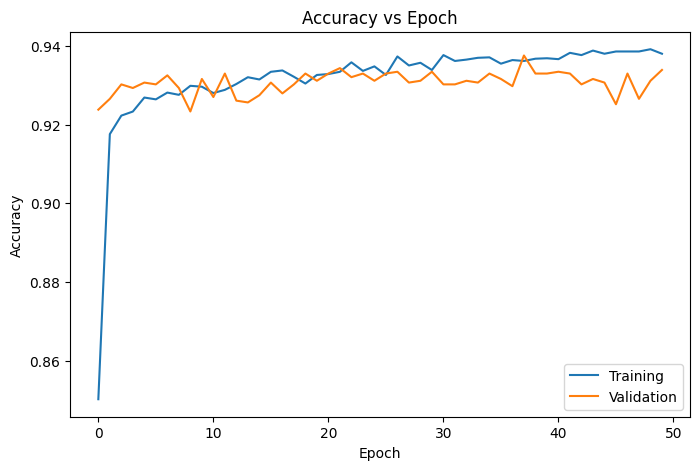

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training", "Validation"])
plt.show()

GRAFIK

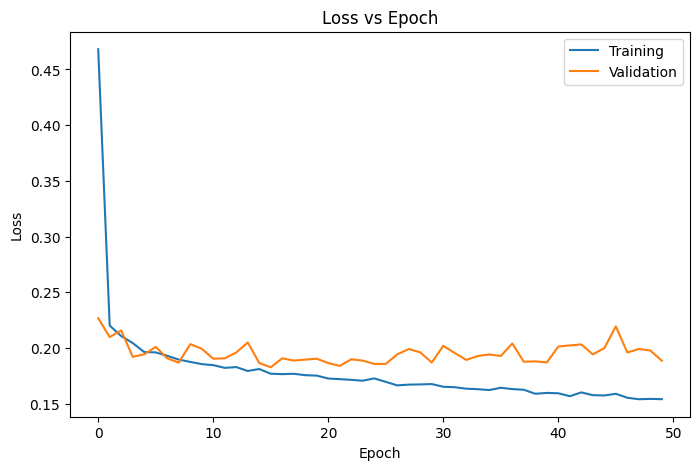

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training",
    "Validation"
])

plt.show()

LOSS

In [18]:
y_pred = model.predict(X_test)

print(y_pred[:5])

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[8.20224055e-10 4.44716009e-12 1.91149820e-06 4.76196771e-09
  9.99920249e-01 1.28669658e-10 7.77816022e-05]
 [3.15357087e-04 4.83376894e-09 8.03331568e-05 1.97906593e-05
  8.43966193e-03 1.74374101e-04 9.90970373e-01]
 [7.61735797e-01 5.24759969e-07 2.38205388e-01 1.09664396e-16
  5.81249187e-05 5.28566773e-08 1.50229283e-07]
 [1.69270493e-06 2.92827913e-08 1.07287281e-06 9.64510262e-01
  1.31665543e-02 1.43693498e-04 2.21767072e-02]
 [1.49749429e-03 3.97652627e-07 4.03308717e-04 1.25146881e-01
  5.63732162e-03 3.89480568e-03 8.63419712e-01]]


In [19]:
y_pred_class = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test.values, axis=1)

print("Prediksi :", y_pred_class[:10])
print("Asli     :", y_true[:10])

Prediksi : [4 6 0 3 6 2 3 2 6 6]
Asli     : [4 6 0 3 6 2 3 2 6 3]


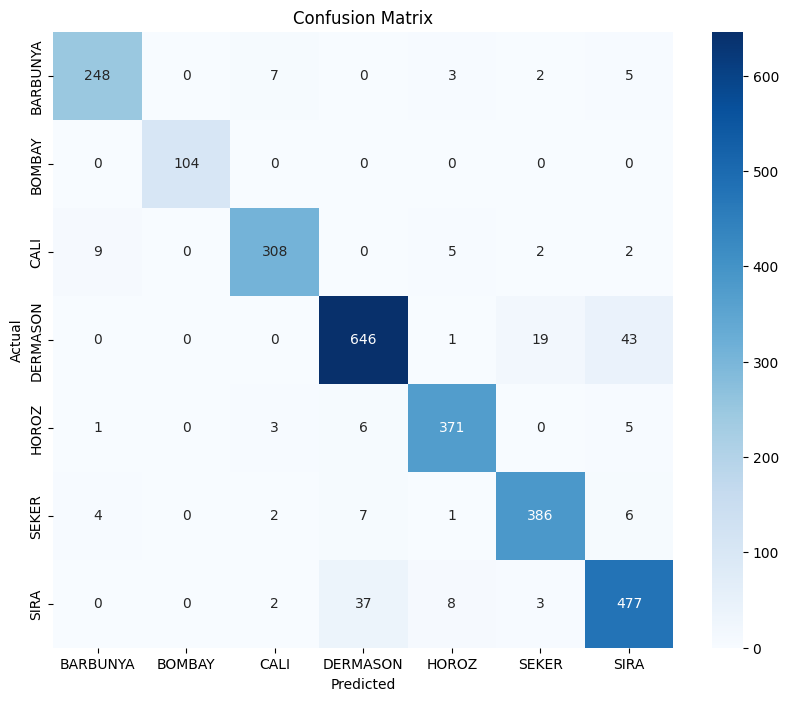

In [20]:
cm = confusion_matrix(
    y_true,
    y_pred_class
)

classes = [
    "BARBUNYA",
    "BOMBAY",
    "CALI",
    "DERMASON",
    "HOROZ",
    "SEKER",
    "SIRA"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [21]:
def build_model(neuron):

    model = Sequential([

        Input(shape=(16,)),

        Dense(
            neuron,
            activation='relu'
        ),

        Dense(
            7,
            activation='softmax'
        )

    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [22]:
neurons = [16,32,64,128]

hasil = []

for n in neurons:

    print(f"\nNeuron = {n}")

    model = build_model(n)

    model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=32,
        verbose=0
    )

    loss, acc = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    hasil.append([
        n,
        acc,
        loss
    ])

    print(
        "Accuracy:",
        round(acc,4)
    )


Neuron = 16
Accuracy: 0.9218

Neuron = 32
Accuracy: 0.9277

Neuron = 64
Accuracy: 0.9291

Neuron = 128
Accuracy: 0.931


In [23]:
hasil_df = pd.DataFrame(
    hasil,
    columns=[
        "Neuron",
        "Accuracy",
        "Loss"
    ]
)

hasil_df

,Neuron,Accuracy,Loss
0,16,0.921777,0.214404
1,32,0.927653,0.202696
2,64,0.929122,0.201540
3,128,0.930959,0.196782


eksperimen hyperparameter

In [24]:
def build_layer_model(num_layer):

    model = Sequential()

    model.add(
        Input(shape=(16,))
    )

    for i in range(num_layer):

        model.add(
            Dense(
                64,
                activation='relu'
            )
        )

    model.add(
        Dense(
            7,
            activation='softmax'
        )
    )

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [25]:
layers = [1,2,3]

hasil_layer = []

for l in layers:

    print(f"\nHidden Layer = {l}")

    model = build_layer_model(l)

    model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=32,
        verbose=0
    )

    loss, acc = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    hasil_layer.append([
        l,
        acc,
        loss
    ])

    print(
        "Accuracy:",
        round(acc,4)
    )


Hidden Layer = 1
Accuracy: 0.9247

Hidden Layer = 2
Accuracy: 0.9269

Hidden Layer = 3
Accuracy: 0.931


In [26]:
layer_df = pd.DataFrame(
    hasil_layer,
    columns=[
        "Hidden Layer",
        "Accuracy",
        "Loss"
    ]
)

layer_df

,Hidden Layer,Accuracy,Loss
0,1,0.924715,0.200023
1,2,0.926919,0.202899
2,3,0.930959,0.202072


Eksperimen Hidden Layer

In [27]:
def build_lr_model(lr):

    model = Sequential([

        Input(shape=(16,)),

        Dense(
            64,
            activation='relu'
        ),

        Dense(
            7,
            activation='softmax'
        )

    ])

    model.compile(

        optimizer=Adam(
            learning_rate=lr
        ),

        loss='categorical_crossentropy',

        metrics=['accuracy']
    )

    return model

    

In [28]:
learning_rates = [
    0.1,
    0.01,
    0.001
]

hasil_lr = []

for lr in learning_rates:

    print(f"\nLearning Rate = {lr}")

    model = build_lr_model(lr)

    model.fit(

        X_train,
        y_train,

        epochs=20,

        batch_size=32,

        verbose=0
    )

    loss, acc = model.evaluate(

        X_test,
        y_test,

        verbose=0
    )

    hasil_lr.append([
        lr,
        acc,
        loss
    ])

    print(
        "Accuracy:",
        round(acc,4)
    )


Learning Rate = 0.1
Accuracy: 0.9163

Learning Rate = 0.01
Accuracy: 0.9306

Learning Rate = 0.001
Accuracy: 0.9313


In [29]:
lr_df = pd.DataFrame(

    hasil_lr,

    columns=[
        "Learning Rate",
        "Accuracy",
        "Loss"
    ]
)

lr_df

,Learning Rate,Accuracy,Loss
0,0.100,0.916269,0.294520
1,0.010,0.930591,0.213523
2,0.001,0.931326,0.196799


Learning rate

In [30]:
def build_batch_model():

    model = Sequential([

        Input(shape=(16,)),

        Dense(
            64,
            activation='relu'
        ),

        Dense(
            7,
            activation='softmax'
        )

    ])

    model.compile(

        optimizer='adam',

        loss='categorical_crossentropy',

        metrics=['accuracy']

    )

    return model

In [31]:
batch_sizes = [
    16,
    32,
    64
]

hasil_batch = []

for bs in batch_sizes:

    print(f"\nBatch Size = {bs}")

    model = build_batch_model()

    model.fit(

        X_train,
        y_train,

        epochs=20,

        batch_size=bs,

        verbose=0
    )

    loss, acc = model.evaluate(

        X_test,
        y_test,

        verbose=0
    )

    hasil_batch.append([
        bs,
        acc,
        loss
    ])

    print(
        "Accuracy:",
        round(acc,4)
    )


Batch Size = 16
Accuracy: 0.9328

Batch Size = 32
Accuracy: 0.9273

Batch Size = 64
Accuracy: 0.9221


In [32]:
batch_df = pd.DataFrame(

    hasil_batch,

    columns=[
        "Batch Size",
        "Accuracy",
        "Loss"
    ]

)

batch_df

,Batch Size,Accuracy,Loss
0,16,0.932795,0.193297
1,32,0.927286,0.201599
2,64,0.922145,0.209342


In [33]:
def build_epoch_model():

    model = Sequential([

        Input(shape=(16,)),

        Dense(
            64,
            activation='relu'
        ),

        Dense(
            7,
            activation='softmax'
        )

    ])

    model.compile(

        optimizer=Adam(
            learning_rate=0.01
        ),

        loss='categorical_crossentropy',

        metrics=['accuracy']

    )

    return model

In [34]:
epochs_list = [
    50,
    100,
    200
]

hasil_epoch = []

for ep in epochs_list:

    print(f"\nEpoch = {ep}")

    model = build_epoch_model()

    model.fit(

        X_train,
        y_train,

        epochs=ep,

        batch_size=16,

        verbose=0
    )

    loss, acc = model.evaluate(

        X_test,
        y_test,

        verbose=0
    )

    hasil_epoch.append([
        ep,
        acc,
        loss
    ])

    print(
        "Accuracy:",
        round(acc,4)
    )


Epoch = 50
Accuracy: 0.9346

Epoch = 100
Accuracy: 0.9277

Epoch = 200
Accuracy: 0.9379


In [35]:
epoch_df = pd.DataFrame(

    hasil_epoch,

    columns=[
        "Epoch",
        "Accuracy",
        "Loss"
    ]

)

epoch_df

,Epoch,Accuracy,Loss
0,50,0.934631,0.253459
1,100,0.927653,0.234839
2,200,0.937936,0.396115


epoch

In [36]:
from tensorflow.keras.initializers import (
    Zeros,
    RandomUniform,
    RandomNormal,
    GlorotUniform,
    HeNormal
)
from tensorflow.keras.optimizers import Adam
def build_init_model(init):
    model = Sequential([
        Input(shape=(16,)),
        Dense(
            64,
            activation='relu',
            kernel_initializer=init
        ),

        Dense(
            7,
            activation='softmax'
        )

    ])

    model.compile(

        optimizer=Adam(
            learning_rate=0.01
        ),

        loss='categorical_crossentropy',

        metrics=['accuracy']

    )

    return model

In [37]:
initializers = {

    "Zero": Zeros(),

    "Uniform": RandomUniform(),

    "Normal": RandomNormal(),

    "Xavier": GlorotUniform(),

    "He": HeNormal()
}

hasil_init = []

for nama, init in initializers.items():

    print(f"\n{nama}")

    model = build_init_model(init)

    model.fit(

        X_train,
        y_train,

        epochs=20,

        batch_size=16,

        verbose=0
    )

    loss, acc = model.evaluate(

        X_test,
        y_test,

        verbose=0
    )

    hasil_init.append([
        nama,
        acc,
        loss
    ])

    print(
        "Accuracy:",
        round(acc,4)
    )


Zero
Accuracy: 0.2604

Uniform
Accuracy: 0.9291

Normal
Accuracy: 0.9328

Xavier
Accuracy: 0.9221

He
Accuracy: 0.928


In [38]:
init_df = pd.DataFrame(

    hasil_init,

    columns=[
        "Initialization",
        "Accuracy",
        "Loss"
    ]

)

init_df

,Initialization,Accuracy,Loss
0,Zero,0.260375,1.835307
1,Uniform,0.929122,0.219895
2,Normal,0.932795,0.230559
3,Xavier,0.922145,0.228439
4,He,0.928021,0.225290


Eksperimen Inisialisasi Bobot